
# 01 — เตรียมข้อมูล (Preprocessing) และการสังเคราะห์ข้อมูล (Data Augmentation)

Notebook นี้ทำ 4 เรื่องหลัก:
1. แบ่งข้อมูลเป็น Train/Validation แบบ **stratified 80/20** (พร้อมกฎพิเศษรองรับคลาสที่มีข้อมูลน้อยมาก ตามที่พบใน EDA)
2. อธิบาย+สาธิตการทำความสะอาด/normalize ภาพ (grayscale→RGB, resize, ปรับค่าพิกเซล)
3. อธิบาย+สาธิตเทคนิค Data Augmentation ที่เลือกใช้ พร้อมเหตุผลว่าทำไมถึง **ห้ามใช้ flip**
4. อธิบาย+เลือกวิธีจัดการ Class Imbalance ที่จะใช้ตอนฝึกสอน (notebook 03)

ผลลัพธ์จาก notebook นี้ (ไฟล์ split และ cache ของภาพที่ resize แล้ว) จะถูกใช้ต่อใน notebook 02–04


In [1]:

%matplotlib inline
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data_utils import list_images, stratified_split, save_split, class_counts_table
from src.augmentation import load_and_resize, random_rotation, random_shift, random_zoom, random_shear, \
    random_brightness_contrast, gaussian_noise, elastic_transform, random_erasing, augment_image
from src.pipeline import build_label_maps, build_or_load_cache, IMG_SIZE
from src.viz_utils import show_image_grid, savefig

rng = np.random.RandomState(42)
print("Target image size for the model input:", IMG_SIZE, "x", IMG_SIZE)


Target image size for the model input: 96 x 96


## 1. แบ่งข้อมูล Train / Validation (Stratified 80/20)


**ปัญหาที่ต้องแก้ก่อน:** จาก EDA พบว่ามี 2 คลาส (`163`, `177`) ที่มีภาพเพียง **คลาสละ 1 ภาพ** การแบ่งแบบ stratified มาตรฐาน (เช่น `sklearn.train_test_split(..., stratify=...)`) จะ**error ทันที** เพราะไม่สามารถแบ่งคลาสที่มีสมาชิกเดียวให้อยู่ทั้งสอง split ได้

**กฎการแบ่งข้อมูลที่ใช้ในโปรเจคนี้** (ดู `src/data_utils.stratified_split`):
- คลาสที่มีภาพ **≥ 5 ภาพ**: แบ่งตามสัดส่วน 80/20 ตามปกติ (val อย่างน้อย 1 ภาพ)
- คลาสที่มีภาพ **2–4 ภาพ**: ใส่ไป Validation 1 ภาพ ที่เหลือเข้า Train (พยายามให้ทุกคลาสมีตัวแทนใน validation เท่าที่ทำได้)
- คลาสที่มีภาพ **1 ภาพ**: ภาพเดียวนั้นเข้า Train ทั้งหมด — คลาสนี้จะ**ไม่มีตัวแทนใน Validation เลย** (เป็นข้อจำกัดที่หลีกเลี่ยงไม่ได้จากข้อมูลที่มี ไม่ใช่บั๊กของโค้ด)


In [2]:

df = list_images()
df = stratified_split(df, val_fraction=0.2, random_state=42)
save_split(df)

split_summary = df.groupby(["class_id", "split"]).size().unstack(fill_value=0)
split_summary["total"] = split_summary.sum(axis=1)
split_summary["val_fraction_actual"] = (split_summary.get("val", 0) / split_summary["total"]).round(3)
split_summary = split_summary.sort_values("total", ascending=False)
print(f"บันทึกผลการแบ่งไปที่ outputs/split.csv แล้ว")
print(f"\nจำนวนรวม: train={int(split_summary['train'].sum())}, val={int(split_summary.get('val', pd.Series([0])).sum())}")
split_summary


บันทึกผลการแบ่งไปที่ outputs/split.csv แล้ว

จำนวนรวม: train=50162, val=12545


split,train,val,total,val_fraction_actual
class_id,,,,
210,4020,1005,5025,0.200
185,3890,973,4863,0.200
195,3730,933,4663,0.200
209,3296,824,4120,0.200
193,2645,661,3306,0.200
...,...,...,...,...
206,8,2,10,0.200
247,3,1,4,0.250
204,2,1,3,0.333


In [3]:

zero_val_classes = split_summary[split_summary.get("val", 0) == 0]
print(f"คลาสที่ไม่มีตัวแทนใน Validation เลย: {list(zero_val_classes.index)} "
      f"({len(zero_val_classes)} คลาส จาก {len(split_summary)} คลาสทั้งหมด)")
overall_val_frac = df["split"].value_counts(normalize=True).get("val", 0)
print(f"สัดส่วน Validation โดยรวมของทั้งชุดข้อมูล: {overall_val_frac:.1%} (ใกล้เคียง 20% ตามเป้าหมาย)")


คลาสที่ไม่มีตัวแทนใน Validation เลย: ['163', '177'] (2 คลาส จาก 72 คลาสทั้งหมด)
สัดส่วน Validation โดยรวมของทั้งชุดข้อมูล: 20.0% (ใกล้เคียง 20% ตามเป้าหมาย)



**สรุป:** ได้สัดส่วน Validation โดยรวม ~20% ตามเป้าหมาย มีเพียง 2 คลาส (ที่มีข้อมูล 1 ภาพ) ที่ไม่มีตัวแทนใน Validation ซึ่งเป็นข้อจำกัดที่ระบุไว้อย่างชัดเจนแล้ว — ผลกระทบคือ accuracy/recall ของ 2 คลาสนี้จะวัดไม่ได้จาก validation set (แต่โมเดลยังคงเห็นภาพนี้ตอน train และพยายามทำนายได้ตอนใช้งานจริง)


## 2. ทำความสะอาดและ Normalize ภาพ


ภาพต้นฉบับเป็น grayscale (โหมด `L`) ขนาดเล็กมาก (median ~16×19 พิกเซล) ในขณะที่ backbone pretrained ที่จะใช้ (MobileNetV2 / EfficientNetB0) ต้องการ input เป็น **3-channel RGB** ขั้นตอนเตรียมข้อมูลจึงมี:

1. **Grayscale → RGB**: ทำซ้ำช่องสัญญาณเดียวกัน 3 ครั้ง (`L` → `RGB`) เพื่อให้ backbone ใช้งานได้ โดยไม่สร้างข้อมูลสีปลอมขึ้นมา
2. **Resize** เป็น 96×96 พิกเซล ด้วย bicubic interpolation — เลือก 96×96 เพราะ (ก) เป็นหนึ่งใน input size มาตรฐานที่ Keras มีน้ำหนัก MobileNetV2 pretrained ให้โดยตรง (ไม่ต้องเทรนใหม่ตั้งแต่ต้น) (ข) เล็กพอที่จะฝึกสอนได้เร็วบนเครื่องที่ไม่มี GPU สำหรับ TensorFlow บน Windows (ค) ยังคงใหญ่กว่าภาพต้นฉบับมากพอที่จะให้รายละเอียดเส้นตัวอักษรหลังขยายภาพยังพอสังเกตได้
3. **ปรับค่าพิกเซล (normalize)**: ใช้ฟังก์ชัน `preprocess_input` ของแต่ละ backbone (ฝังไว้เป็น layer แรกของโมเดลใน notebook 02) ซึ่งจะ scale ค่าพิกเซลให้อยู่ในช่วงที่ backbone นั้น ๆ ถูกเทรนมา (เช่น [-1, 1] สำหรับ MobileNetV2)
</cell id="88c726d1">


ต้นฉบับ: L (11, 18)
หลังแปลง: (96, 96, 3) uint8
Saved figure -> C:\Users\Acer\Desktop\deep\outputs\figures\01_preprocess_before_after.png


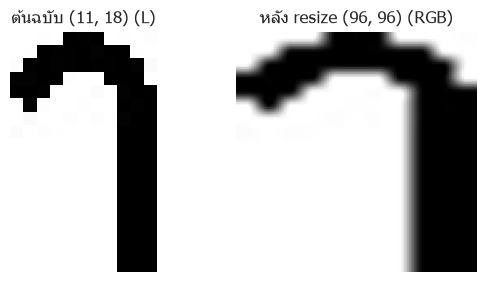

In [4]:

sample_row = df[df["class_id"] == split_summary.index[0]].iloc[0]
from PIL import Image
with Image.open(sample_row["filepath"]) as im:
    original = im.copy()
    print("ต้นฉบับ:", original.mode, original.size)

resized = load_and_resize(sample_row["filepath"], size=IMG_SIZE)
print("หลังแปลง:", resized.shape, resized.dtype)

fig, axes = plt.subplots(1, 2, figsize=(6, 3))
axes[0].imshow(original, cmap="gray")
axes[0].set_title(f"ต้นฉบับ {original.size} (L)")
axes[0].axis("off")
axes[1].imshow(resized)
axes[1].set_title(f"หลัง resize {resized.shape[:2]} (RGB)")
axes[1].axis("off")
fig.tight_layout()
savefig(fig, "01_preprocess_before_after.png")
plt.show()


## 3. Data Augmentation


### กฎเหล็กของโปรเจคนี้: ห้ามใช้ horizontal / vertical flip เด็ดขาด
การ flip ภาพตัวอักษรสามารถเปลี่ยนตัวอักษรให้กลายเป็นอักขระอื่น หรือกลายเป็นรูปที่ไม่มีความหมายในภาษาไทยได้ทันที (ตัวอักษรไทยจำนวนมากไม่มีสมมาตรแนวตั้ง/แนวนอน) ซึ่งจะเป็นการใส่ label ที่ผิดเข้าไปในข้อมูลฝึกสอนโดยตรง เทคนิคทั้งหมดที่เลือกใช้ด้านล่างจึงเน้นเฉพาะการบิดเบือนภาพในลักษณะที่ **ลายมือจริงสามารถแปรผันได้เองตามธรรมชาติ** โดยไม่เปลี่ยนความหมายของตัวอักษร

| เทคนิค | คืออะไร | ทำไมถึงเลือกใช้ |
|---|---|---|
| Random Rotation (±12°) | หมุนภาพเล็กน้อย | จำลองมุมเอียงตามธรรมชาติของการเขียนด้วยมือ |
| Width/Height Shift (±8%) | เลื่อนตำแหน่งภาพ | จำลองตำแหน่งตัวอักษรที่ไม่ได้อยู่กึ่งกลางเป๊ะเสมอไป |
| Random Zoom (90–110%) | ย่อ/ขยายภาพเล็กน้อย | จำลองขนาดตัวอักษรที่แตกต่างกันตามแรงกด/ปากกาของผู้เขียนแต่ละคน |
| Random Shear (±0.15 rad) | บิดเฉือนภาพ | จำลองลายมือเอียง/เฉียงแบบลายมือคนจริง |
| Brightness/Contrast (±15%) | ปรับความสว่าง/คอนทราสต์ | จำลองความเข้มหมึกที่แตกต่างกัน หรือแสงตอนสแกน/ถ่ายภาพ |
| Gaussian Noise (σ=6) | เพิ่ม noise สุ่มแบบ Gaussian | จำลองสัญญาณรบกวนจากเซนเซอร์กล้อง/สแกนเนอร์ |
| Elastic Transform | บิดเบือนภาพแบบยืดหยุ่นเฉพาะจุด (Simard et al.) | จำลองความไม่สม่ำเสมอ/สั่นของเส้นลายมือ โดยไม่เปลี่ยนโครงสร้างโดยรวมของตัวอักษร (ต่างจาก flip ที่เปลี่ยนโครงสร้างทั้งหมด) |
| Random Erasing (Cutout) | ลบพื้นที่สี่เหลี่ยมเล็ก ๆ แบบสุ่ม | จำลากหมึกจางบางส่วน/รอยเปื้อน บังคับให้โมเดลไม่พึ่งพาเส้นใดเส้นหนึ่งมากเกินไป |

แต่ละเทคนิคถูกใช้แบบสุ่มอิสระ (มีโอกาส 50% ต่อภาพต่อเทคนิคที่จะถูกใช้งาน) ดู `src/augmentation.py::augment_image`


Saved figure -> C:\Users\Acer\Desktop\deep\outputs\figures\01_augmentation_before_after.png


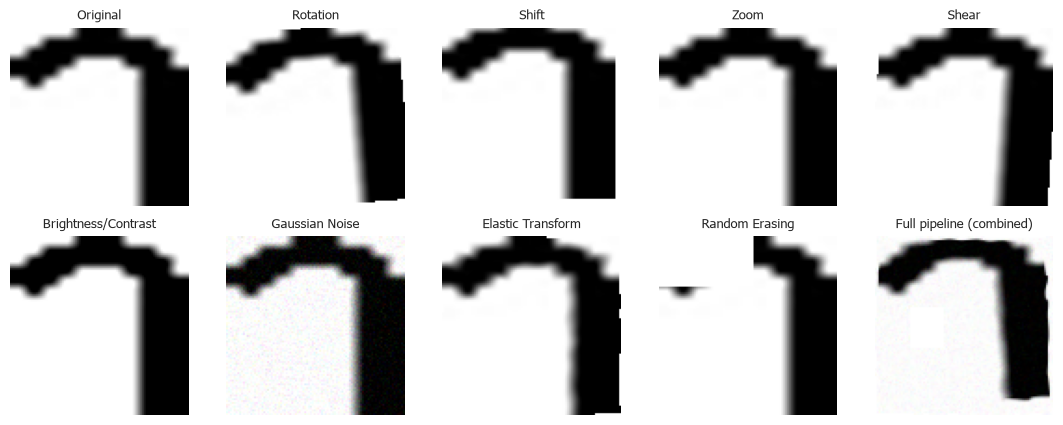

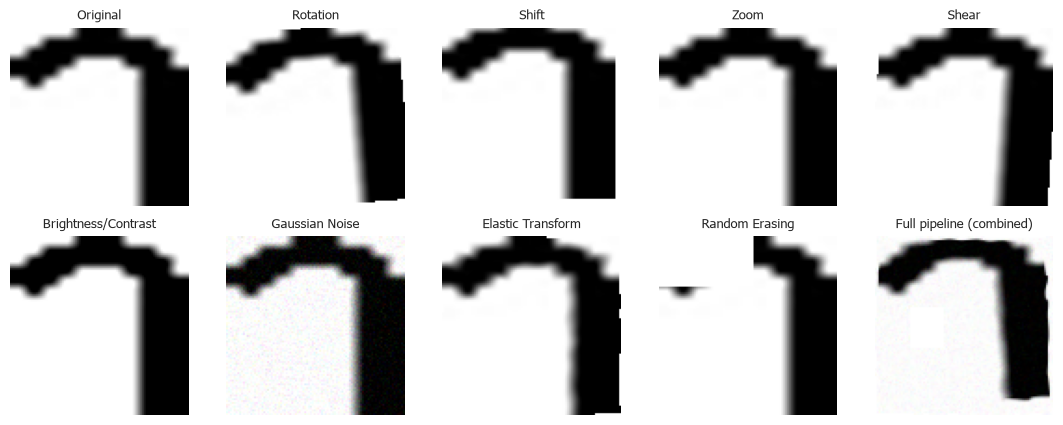

In [5]:

sample_img = load_and_resize(sample_row["filepath"], size=IMG_SIZE)

techniques = [
    ("Original", lambda im, r: im),
    ("Rotation", lambda im, r: random_rotation(im, 12.0, r)),
    ("Shift", lambda im, r: random_shift(im, 0.08, r)),
    ("Zoom", lambda im, r: random_zoom(im, (0.9, 1.1), r)),
    ("Shear", lambda im, r: random_shear(im, 0.15, r)),
    ("Brightness/Contrast", lambda im, r: random_brightness_contrast(im, rng=r)),
    ("Gaussian Noise", lambda im, r: gaussian_noise(im, 10.0, r)),
    ("Elastic Transform", lambda im, r: elastic_transform(im, 8.0, 3.0, r)),
    ("Random Erasing", lambda im, r: random_erasing(im, 0.15, r)),
    ("Full pipeline (combined)", lambda im, r: augment_image(im, r, apply_prob=0.7)),
]

r = np.random.RandomState(123)
imgs = [fn(sample_img, r) for _, fn in techniques]
titles = [name for name, _ in techniques]
show_image_grid(imgs, titles, ncols=5, name="01_augmentation_before_after.png", figsize_scale=2.2)



สังเกตว่าทุกภาพหลัง augment ยังคง**อ่านออกว่าเป็นตัวอักษรเดิม**ได้ชัดเจน เพียงแต่มีความแปรผันของตำแหน่ง/มุม/ความเข้ม/สัญญาณรบกวนเท่านั้น ตรงข้ามกับการทำ horizontal flip ที่จะเปลี่ยนโครงสร้างตัวอักษรทั้งหมดทันที


## 4. การจัดการ Class Imbalance


จาก EDA พบว่าอัตราส่วนภาพระหว่างคลาสมากสุด/น้อยสุดต่างกันกว่า 5,000 เท่า วิธีที่พิจารณา:

| วิธี | ข้อดี | ข้อเสีย |
|---|---|---|
| `class_weight` (inverse frequency) | ใช้ง่าย ไม่ต้องแก้ loss function | ให้น้ำหนักเท่ากันทุกตัวอย่างในคลาสเดียวกัน ไม่แยกแยะตัวอย่างง่าย/ยาก |
| Oversampling คลาสน้อยด้วย augmentation เพิ่ม | เพิ่มจำนวนตัวอย่างจริง | เสี่ยง overfit ซ้ำกับภาพที่ augment จากต้นฉบับเดิมไม่กี่ภาพ (โดยเฉพาะคลาสที่มีแค่ 1 ภาพ) |
| **Focal Loss** (เลือกใช้) | ลดน้ำหนักตัวอย่างที่โมเดลมั่นใจแล้ว (easy examples) โดยอัตโนมัติ ไม่ว่าจะอยู่คลาสไหน ทำให้ gradient ไปโฟกัสที่ตัวอย่างยาก/คลาสส่วนน้อยมากขึ้นโดยธรรมชาติ ไม่ต้องเพิ่ม/ลดจำนวนข้อมูลจริง | ต้อง tune hyperparameter เพิ่ม (gamma) |

**เราเลือกใช้ Focal Loss** (`src/model_utils.sparse_categorical_focal_loss`, gamma=2.0) เป็นเทคนิคหลักในการจัดการ imbalance ตอนฝึกสอน (notebook 03) เพราะเหมาะกับสถานการณ์ที่ imbalance รุนแรงมาก (กว่า 5,000 เท่า) และไม่ต้องการเพิ่มความเสี่ยง overfitting จากการ oversample ภาพที่มีต้นฉบับน้อยมากซ้ำ ๆ
</cell id="aee9a635">


In [6]:

counts = class_counts_table(df)
counts["inverse_freq_weight"] = (counts["count"].sum() / (len(counts) * counts["count"])).round(3)
print("ตัวอย่าง class_weight แบบ inverse-frequency (เพื่อเปรียบเทียบ แม้จะไม่ได้เลือกใช้เป็นหลัก):")
counts.sort_values("count").head(8)


ตัวอย่าง class_weight แบบ inverse-frequency (เพื่อเปรียบเทียบ แม้จะไม่ได้เลือกใช้เป็นหลัก):


,class_id,count,inverse_freq_weight
71,177,1,870.931
70,163,1,870.931
69,204,3,290.310
68,247,4,217.733
67,206,10,87.093
66,246,12,72.578
65,196,13,66.995
64,214,14,62.209


## 5. Precompute ภาพที่ resize แล้ว (Cache) สำหรับใช้ฝึกสอน


เนื่องจากภาพต้นฉบับมีขนาดเล็กและมีจำนวนมาก (62,707 ภาพ) การ decode+resize ไฟล์ JPEG ทุกภาพซ้ำทุก epoch จะเป็นคอขวดที่ไม่จำเป็น จึงทำการ resize ทุกภาพเป็น 96×96×3 เพียงครั้งเดียว แล้วบันทึกเป็นไฟล์ `.npz` ไว้ที่ `cache/` (ไม่ commit ขึ้น git เพราะไฟล์ใหญ่ — สร้างใหม่ได้เสมอจากเซลล์นี้) เพื่อให้ notebook การฝึกสอน (`03_training.ipynb`) โหลดใช้ได้ทันทีโดยไม่ต้องทำซ้ำ

ขั้นตอนนี้ใช้เวลาประมาณ 5–15 นาที (รันครั้งเดียว)
</cell id="b1864558">


In [7]:

class_to_idx, idx_to_class = build_label_maps(df)
print(f"จำนวนคลาสทั้งหมด: {len(class_to_idx)}")

train_images, train_labels = build_or_load_cache(df, "train", class_to_idx, img_size=IMG_SIZE)
val_images, val_labels = build_or_load_cache(df, "val", class_to_idx, img_size=IMG_SIZE)

print(f"Train cache: {train_images.shape}, labels {train_labels.shape}")
print(f"Val cache:   {val_images.shape}, labels {val_labels.shape}")

import json
from src.data_utils import CACHE_DIR
with open(CACHE_DIR / "class_maps.json", "w", encoding="utf-8") as f:
    json.dump({"class_to_idx": class_to_idx, "idx_to_class": idx_to_class}, f, ensure_ascii=False, indent=2)
print("บันทึก class_to_idx / idx_to_class ไปที่ cache/class_maps.json แล้ว")


จำนวนคลาสทั้งหมด: 72


Caching train:   0%|          | 0/50162 [00:00<?, ?it/s]

Caching train:   0%|          | 191/50162 [00:00<00:26, 1889.54it/s]

Caching train:   1%|          | 380/50162 [00:00<00:26, 1888.79it/s]

Caching train:   1%|          | 575/50162 [00:00<00:25, 1914.83it/s]

...

Caching val:  97%|█████████▋| 12150/12545 [00:07<00:00, 930.96it/s] 

Caching val:  99%|█████████▊| 12367/12545 [00:07<00:00, 1186.47it/s]

Caching val: 100%|█████████▉| 12494/12545 [00:07<00:00, 1156.78it/s]

Caching val: 100%|██████████| 12545/12545 [00:07<00:00, 1663.80it/s]

Train cache: (50162, 96, 96, 3), labels (50162,)
Val cache:   (12545, 96, 96, 3), labels (12545,)
บันทึก class_to_idx / idx_to_class ไปที่ cache/class_maps.json แล้ว



## สรุป Notebook 01

- แบ่งข้อมูล Train/Validation แบบ stratified 80/20 พร้อมกฎพิเศษรองรับคลาสข้อมูลน้อยมาก → บันทึกที่ `outputs/split.csv`
- Normalize ภาพ: grayscale→RGB, resize เป็น 96×96, preprocess ตาม backbone
- เลือกใช้เทคนิค Augmentation 8 แบบที่ไม่ทำลายความหมายตัวอักษร (ไม่ flip)
- เลือก Focal Loss เป็นเทคนิคหลักจัดการ class imbalance
- Cache ภาพที่ resize แล้วไว้ที่ `cache/` สำหรับใช้ฝึกสอนต่อใน notebook 03
